# **<u>Galaxy Morphology Classification</u>**

This project aims to build an image classifier to identify the morphological class of a galaxy from a single image using machine learning techniques. The training images for this are sourced from **Kaggle**, more specifically the [Galaxy Zoo classification](https://www.kaggle.com/datasets/anjosut/galaxy-zoo-classification) dataset which contains ~29,000 galaxy images labelled across 5 different classes:

- cigar-shaped smooth
- completely round smooth
- edge-on
- in between smooth
- spiral

---

The notebook follows a fairly progressive approach:

- Training a scratch-built CNN as a baseline.
- Applying transfer learning with the pretrained **ResNet-18** model.
- Data augmentation for further performance improvements.

---

Ultimately, there is one end-goal in mind, and that is to **<u>feed the model a random galaxy image from the internet and have it correctly predict its morphological class</u>**.

## **<u>Importing libraries and setting a global seed</u>**

Here we import everything needed to run the whole notebook. One thing to note is the final line:

- `torch.backends.cudnn.deterministic = True`.

which ensures **reproducibility** but simultaneously makes the training done later on **slower**. 

In [1]:
import numpy as np
import collections
import torch
import torch.nn as nn
import torchvision.models as models
import matplotlib.pyplot as plt
import seaborn as sns
import os
import random
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import confusion_matrix, classification_report
from PIL import Image


global_seed = 42
torch.manual_seed(global_seed)
torch.cuda.manual_seed(global_seed)
np.random.seed(global_seed)
random.seed(global_seed)
torch.backends.cudnn.deterministic = True

## **<u>Utilising GPU power</u>**

Given that training neural networks involves millions of mathematical operations, it's preferred to switch any models defined later on to the system's dedicated GPU, if there is one, and perform the calculations on there. Otherwise, the CPU is used instead.

> **Note on Hardware and Portability**:
> - This notebook is configured for **NVIDIA GPUs** since my machine contains an <u>NVIDIA RTX 3060 GPU</u> and thus utilises CUDA, which the code explicitly targets for hardware acceleration. If your machine also has an NVIDIA GPU, you can find and install device-compatible versions of PyTorch that support CUDA [HERE](https://pytorch.org/get-started/locally/) if needed.
> - For AMD and Apple Silicon users, the notebook will fall back to the CPU by default. As a result, training times will be longer but functionality stays the same. <u>See the README file for more information on compatibility and support.</u>
>
> **Troubleshooting**:
> - If you have an NVIDIA GPU but it's not being detected, check that the version of `torch` you are running is compatible with CUDA.

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if torch.cuda.is_available():
    print(f"GPU detected: {torch.cuda.get_device_name(0)}")
else:
    print(f"No GPU detected. Using CPU instead")

GPU detected: NVIDIA GeForce RTX 3060


## **<u>1) Preprocessing the data</u>**

Firstly, we utilise `datasets` and `transforms` from **torchvision**.

---

1. Transform components:
   - `Compose` allows for chaining multiple transformations together in order.
   - `Resize` scales the images down to **64x64** pixels.
   - `ToTensor` converts Python image files into a 3D array of numbers and normalises the pixel values from **0-255 to 0-1.**

---

2. Loading dataset:
   - `ImageFolder` loads in the galaxy images contained in subfolders within the parent images folder (in this case **Train_images**).

---
  
3. An **80/20 training/testing** split is done so that the classifier learns from **80%** of the data and the remaining **20%** is used for evaluating on new, unseen data. As the name suggests, `random_split` ensures this is done randomly.

---

4. `DataLoader` helps with more efficient image loading. In each case we send 32 images at a time to the classifier:
   - `train_loader` contains `shuffle = True` which randomises the order of images loaded for each epoch.
   - `test_loader` contains `shuffle = False` since we only care about consistent evaluation and not about order.

In [3]:
# allows preprocessing of images
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

# loading data
dataset = datasets.ImageFolder(
    root = 'Train_images',
    transform = transform
)

# 80/20 split
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

# create dataloaders
train_loader = DataLoader(train_dataset, batch_size = 32, shuffle = True)
test_loader = DataLoader(test_dataset, batch_size = 32, shuffle = False)

## **<u>2) Building a Baseline CNN</u>**

Now that the data has been processed, we build the CNN which consists of a repetition of convolutional blocks, fully connected layers and PyTorch's `forward()` function:

---

1. Convolutional blocks:
   - `Conv2D` scans the images and looks for different patterns.
   - `in_channels` represents the number of input channels. We start with **3** for RGB colour channels then increase this the more blocks we use. In each case, the value of `in_channels` in one block matches the value of `out_channels` in the next block.
   - `out_channels` represents the number of features the model will look for, doubling for each block to look for complex patterns.
   - `kernel_size` is the pixel size of the filter that `Conv2D` uses to scan the images (in this case **3x3** pixels).
   - `padding` adds a border of zeroes around each image before the filter is applied to preserve spatial dimensions.
   - `ReLU` activation function which sets negative values to zero.
   - `MaxPool2d` halves the spatial dimensions of each image, thus retaining only the strongest signals and making the model more robust to small feature shifts. Eventually, the dimensions go from **64** to **8**. `stride` is essentially the step size of the **2x2** pixel filter and thus the filter moves 2 pixels at a time with no overlap (because here `kernel_size` = `stride`).

---

2. Fully connected layers:
   - `nn.Flatten()` converts the 3D output of the convolutional blocks (**8x8x128**) into a 1D vector of length **8192**.
   - `nn.Linear(8x8x128, 256)` is the *first* connected layer which takes all **8192** input values and maps them to **256** output neurons.
   - `ReLU` activation same as before for non-linearity.
   - `nn.Dropout(p = 0.5)` to prevent overfitting. **50%** of neurons are randomly 'switched off', forcing the network to learn more distributed representations of the data.
   - `nn.Linear(256, num_classes)` is the *final* connected layer which produces **5** output values (one for each galaxy class we have).

---

3. PyTorch's `forward()` function just produces some output from some input:
   - `x` is the input which represents the batch of images.
   - Each `self` line (self1, self2, self3) just applies the convolution first, then ReLU and finally the pool.

In [4]:
class galaxy_CNN(nn.Module):
    """
    A 3-block CNN for galaxy classification. Each convolutional block extracts features from an input image,
    followed by fully connected layers for class predictions.

    Args:
        num_classes: number of galaxy classes we have (5 by default).
    """
    
    def __init__(self, num_classes = 5):
        super(galaxy_CNN, self).__init__()

        # first conv block
        self.conv1 = nn.Conv2d(in_channels = 3, out_channels = 32, kernel_size = 3, padding = 1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size = 2, stride = 2)
        # image spatial dimensions go from 64x64x3 to 32x32x32

        
        # second conv block
        self.conv2 = nn.Conv2d(in_channels = 32, out_channels = 64, kernel_size = 3, padding = 1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size = 2, stride = 2)
        # image spatial dimensions go from 32x32x32 to 16x16x64

        
        # third conv block
        self.conv3 = nn.Conv2d(in_channels = 64, out_channels = 128, kernel_size = 3, padding = 1)
        self.relu3 = nn.ReLU()
        self.pool3 = nn.MaxPool2d(kernel_size = 2, stride = 2)
        # image spatial dimensions go from 16x16x64 to 8x8x128

        
        # connected layer
        self.flatten = nn.Flatten()
        self.c1 = nn.Linear(8 * 8 * 128, 256)
        self.relu4 = nn.ReLU()
        self.dropout = nn.Dropout(p = 0.5)
        self.c2 = nn.Linear(256, num_classes)

    
    def forward(self, x):
        """
        Defines the forward pass through the neural network.

        Args:
            x: input image batch of shape: (batch_size, 3, 64, 64).

        Returns:
            x: raw class scores of shape: (batch_size, num_classes).
        """
        
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = self.pool3(self.relu3(self.conv3(x)))
        x = self.flatten(x)
        x = self.relu4(self.c1(x))
        x = self.dropout(x)
        x = self.c2(x)

        return x

model = galaxy_CNN(num_classes = 5)
model = model.to(device) # moves the model to the GPU

### **<u>2.1) Some data checks</u>**

---

- Total number of images we have.
- Galaxy classes.
- Training and testing size.
- How many images we have for each class.

In [5]:
print(f"Total images = {len(dataset)}")
print(f"Classes = {dataset.classes}")
print(f"Train size = {len(train_dataset)}")
print(f"Test size = {len(test_dataset)}")
print()

class_counts = {dataset.classes[i]: count for i, count in sorted(collections.Counter(dataset.targets).items())}
for cc, count in class_counts.items():
    print(f"{cc} = {count}")

Total images = 28793
Classes = ['Cigar-shaped smooth', 'In between smooth', 'completely round smooth', 'edge-on', 'spiral']
Train size = 23034
Test size = 5759

Cigar-shaped smooth = 579
In between smooth = 8069
completely round smooth = 8436
edge-on = 3903
spiral = 7806


### **<u>2.2) Adjusting for class weights</u>**

The counts indicate a significant imbalance in the galaxy classes so we must introduce **weights**. By doing this, we avoid training a model that *could* learn to, for the most part, ignore **cigar-shaped galaxies** since getting these wrong wouldn't affect the overall loss as much. This is the same principle as ignoring two 1-mark questions in an exam as opposed to ignoring two 10-mark questions.

---

1. Weighting and Loss function:
   - Conversion from a generic Python list to a PyTorch `tensor`.
   - Dividing **1** by `class_counts` ensures classes with lower frequencies get higher weights.
   - Dividing by `.sum()` for normalisation.
   - Moving them to the GPU, same as before, with `.to(device)`
   - `CrossEntropyLoss` which applies a `softmax` activation function to convert raw model ouputs to probabilities and then measures how far these are from the true labels.
   - Apply the calculated class weights to `CrossEntropyLoss` to avoid the issue of ignoring the lower-frequency classes.

---

2. Optimiser:
   - `Adam` with a fixed learning rate `lr` of **0.001.**

In [6]:
# loss function and class weights
class_counts = torch.tensor([579, 8069, 8436, 3903, 7806], dtype = torch.float)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum()
class_weights = class_weights.to(device)
criterion = nn.CrossEntropyLoss(weight = class_weights)

# optimiser
optimiser = torch.optim.Adam(model.parameters(), lr = 0.001)

## **<u>3) Scratch-Built Training Loop</u>**

Now we build the training loop over 10 epochs with a nested loop.

---

1. Initialise the training phase:
   - Model is switched to training with `model.train()` which 'activates' the dropout from earlier.
   - Set `train_loss` to 0.0 and `train_correct` to 0. These acts as counters that get reset to zero at the beginning of each epoch and are accumulated throughout the batch loop. `train_loss` is a float since the loss values are decimals but `train_correct` is an integer because we count whole predictions.

---

2. Batch loop:
   - `DataLoader` from the beginning feeds **32** images at a time and each iteration gives one batch.
   - `images` is a tensor of shape `(32, 3, 64, 64)`.
   - `labels` is a tensor of **32** class numbers.
   - Move the batch from the system's RAM to the GPU.

---

3. Forward pass:
   - Pass the batch through the network defined earlier - the three convolutional blocks, etc.
   - `outputs` has the shape `(32, 5)` which corresponds to `(32 images, 5 scores for each galaxy class)`.
   - `criterion` is the weighted `CrossEntropyLoss` from before and lets us compute the loss by comparing each score for each image against the true label.

---

4. Backward pass:
   - Clear gradients from the previous batch with `optimiser.zero_grad()` since PyTorch accumulates them by default. Gradients here are just a measure of how much a change in one value affects another - if a weight is slightly increased/decreased, if and by how much would the loss go up/down.
   - Backpropagation with `loss.backward()` to adjust/update each weight.
   - Update weights with `optimiser.step()` by using the gradients calculated with `loss.backward()`.

---

5. Stat tracking:
   - Convert loss from a PyTorch tensor to a Python number and add this to the total for an average at the end.
   - Find class for each image with the highest score.
   - `torch.max(outputs, 1)` takes the maximum across all 5 class scores and returns the maximum values which are discarded with `_` and their corresponding indices which are the predicted class numbers.
   - Compare the predictions to the true labels element-wise. `sum()` counts **correct predictions** and `item.()` converts these to a Python number.

---

6. Validation phase:
   - Switch the model to evaluation with `model.eval()` and dropout is off. Same principle with `train_loss` and `train_correct` applies here to `test_loss` and `test_correct`.
   - `with torch.no_grad()` makes it so PyTorch doesn't compute or store gradients since we don't update weights during validation.
   - Same for loop as before but *without backward pass* and *weight updates*.

---

7. Computing final stats:
   - Divide the total correct predictions by the total images.
   - Obtain average loss per batch.
   - Print a summary for each epoch with details on accuracy and loss.

In [7]:
num_epochs = 10

# training phase
for epoch in range(num_epochs):
    model.train()
    train_loss, train_correct = 0.0, 0

    # batch loop
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        # forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # backward pass
        optimiser.zero_grad()
        loss.backward()
        optimiser.step()

        # some statistics
        train_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        train_correct += (predicted == labels).sum().item()


    # validation phase
    model.eval()
    test_loss, test_correct = 0.0, 0

    
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            test_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            test_correct += (predicted == labels).sum().item()


    # computing stats
    train_acc = 100 * train_correct / len(train_dataset)
    test_acc = 100 * test_correct / len(test_dataset)
    avg_train_loss = train_loss / len(train_loader)
    avg_test_loss = test_loss / len(test_loader)

    
    print(f"Epoch {epoch + 1} / {num_epochs} | "
          f"Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.1f}% | "
          f"Test Loss: {avg_test_loss:.4f} | Test Acc: {test_acc:.1f}%")

Epoch 1 / 10 | Train Loss: 1.2069 | Train Acc: 49.4% | Test Loss: 0.8527 | Test Acc: 64.1%
Epoch 2 / 10 | Train Loss: 0.7955 | Train Acc: 68.8% | Test Loss: 0.6810 | Test Acc: 75.5%
Epoch 3 / 10 | Train Loss: 0.6582 | Train Acc: 75.3% | Test Loss: 0.5909 | Test Acc: 79.8%
Epoch 4 / 10 | Train Loss: 0.5605 | Train Acc: 79.8% | Test Loss: 0.5266 | Test Acc: 79.5%
Epoch 5 / 10 | Train Loss: 0.4949 | Train Acc: 82.2% | Test Loss: 0.4898 | Test Acc: 82.5%
Epoch 6 / 10 | Train Loss: 0.4396 | Train Acc: 84.9% | Test Loss: 0.4688 | Test Acc: 84.8%
Epoch 7 / 10 | Train Loss: 0.4011 | Train Acc: 85.6% | Test Loss: 0.4432 | Test Acc: 86.0%
Epoch 8 / 10 | Train Loss: 0.3770 | Train Acc: 86.8% | Test Loss: 0.4949 | Test Acc: 84.4%
Epoch 9 / 10 | Train Loss: 0.3346 | Train Acc: 87.8% | Test Loss: 0.4685 | Test Acc: 86.4%
Epoch 10 / 10 | Train Loss: 0.3176 | Train Acc: 88.5% | Test Loss: 0.4952 | Test Acc: 85.4%


## **<u>4) PyTorch's ResNet-18 Pretrained Model</u>**

ResNet-18 is a residual network with 18 layers that can be used for image classification. The idea behind using it is that **residual connections (or skip connections)** exist which can skip over layers within the neural network and prevent gradients from vanishing during backpropagation. Since ResNet has already been pretrained on millions of other images, not necessarily just galaxies, where things like textures and edges are mutual, it makes it ideal for testing in this project since the dataset is actually fairly small. ResNet has other models with many more layers but given our dataset size, **18** is more than powerful and quick enough.

---

1. Downloading ResNet:
   - Loads ResNet-18 with weights pretrained on **ImageNet** consisting of millions of images across **1000** classes.
   - `IMAGENET1K_V1` specifies the version of pretrained weights.

---

2. Freezing parameters:
   - Iterate over every weight (`param`) and **freeze** it with `requires_grad = False` to preserve ResNet's knowledge of visual features.
   - With this, PyTorch does **not** compute gradients for these weights.

---

3. Selective unfreezing:
   - Unfreeze the last two layer groups in ResNet-18 with `requires_grad = True`. This is done because the first two layers detect low-level features for generic imaging tasks while the last two are higher-level which is more critical for galaxy classification.
  
---

4. Output adjustment:
   - ResNet-18's final layer has 1000 output values. `resnet.fc.in_features` obtains the input size to this layer.
   - Replace the final layer with `nn.Linear(num_features, 5)` to match the **5** classes that we have.
   - `Adam` optimiser which is only given the **trainable parameters** with `filter(lambda p: ....)` so that it updates the **3rd, 4th and final layers**.
   - Learning rate `lr = 0.0001` which is **10** times smaller than the previous CNN since the 3rd and 4th layers have good pretrained weights already.

In [8]:
# download and load resnet
resnet = models.resnet18(weights = 'IMAGENET1K_V1')

# freezing
for param in resnet.parameters():
    param.requires_grad = False

# unfreezing
for param in resnet.layer3.parameters():
    param.requires_grad = True
for param in resnet.layer4.parameters():
    param.requires_grad = True

# adjusting output size
num_features = resnet.fc.in_features
resnet.fc = nn.Linear(num_features, 5)
resnet = resnet.to(device)
resnet_optimiser = torch.optim.Adam(
    filter(lambda p: p.requires_grad, resnet.parameters()), lr = 0.0001)

### **<u>4.1) Data preparation for ResNet-18</u>**

Here we prepare the data again but make two separate transforms. Similarly to before:

---

1. Train transform:
   - `Compose` chains multiple transforms together.
   - `Resize` scales the images to **224x224 pixels** which is a requirement for ResNet-18.
   - Data augmentations involve `RandomHorizontalFlip()`, `RandomVerticalFlip()` and `RandomRotation(180)`. The flips are used since there is no sense of direction in space. The rotation is random so training on randomly rotated images forces the model to learn rotation-invariant features.
   - `ColorJitter(...)` varies the brightness and contrast which reflects real galaxy imaging where observing conditions like exposure times and atmospheric effects can differ.
   - `ToTensor` converts Python image files into a PyTorch tensor which restructures the data and normalises the pixel values from **0-255 to 0-1.**
   - `Normalize(...)` uses the `mean` and `std` values across millions of images from **ImageNet** to normalise each colour channel. This function from PyTorch applies the following normalisation to each pixel:

$$\large \color{orange}{z} = \frac{\text{pixel} - \text{mean}}{\text{std}} $$

or mathematically:

$$\huge \color{orange}{z} = \frac{x - \mu}{\sigma} $$

with $z$ being the normalised value of each pixel, and **($x, \mu, \sigma$)** corresponding to **($\text{pixel}, \text{mean}, \text{std}$)**.

---

2. Test transform:
   - Exactly the same process as the **train transform** but without the data augmentations since the testing images are always seen in their original form.
  
---

3. Datasets:
   - Loading the images **twice** with `ImageFolder`. This is done so they can be split with the same indices and we can have different subsets with different transforms.
   - Create an **80/20 training-testing split**.

---

4. Split indices:
   - Makes use of the global seed set at the beginning of the notebook.
   - `torch.randperm(...)` generates a random list of each image index in the dataset which is sliced (first 80% of indices become **training** and the remaining 20% of indices become **testing**). Since we generate indices the same split can be applied to either dataset, regardless of the transforms within them.

---

5. Subsets and dataloaders:
   - `Subset` lets us match specified indices (training to training and testing to testing, each for their corresponding 80% and 20% indices).
   - The same principle applies with `DataLoader` here as it did at the beginning.

In [9]:
# transforms
resnet_train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(180),
    transforms.ColorJitter(brightness = 0.2, contrast = 0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean = [0.485, 0.456, 0.406], std = [0.229, 0.224, 0.225])
])

resnet_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean = [0.485, 0.456, 0.406], std = [0.229, 0.224, 0.225])
])


# datasets
resnet_train_dataset = datasets.ImageFolder(
    root = 'Train_images',
    transform = resnet_train_transform
)

resnet_test_dataset = datasets.ImageFolder(
    root = 'Train_images',
    transform = resnet_test_transform
)


# training-testing split
train_size_resnet = int(0.8 * len(resnet_train_dataset))
test_size_resnet = len(resnet_train_dataset) - train_size_resnet


# indices split
indices = torch.randperm(len(resnet_train_dataset))
train_indices = indices[:train_size_resnet]
test_indices = indices[train_size_resnet:]

# subsets and dataloaders
train_subset = torch.utils.data.Subset(resnet_train_dataset, train_indices)
test_subset = torch.utils.data.Subset(resnet_test_dataset, test_indices)
resnet_train_loader = DataLoader(train_subset, batch_size = 32, shuffle = True)
resnet_test_loader = DataLoader(test_subset, batch_size = 32, shuffle = False)

### **<u>4.2) ResNet-18 Training Loop</u>**

This training loop is almost identical to the previous with some minor changes:

---

- Variable names.
- New resnet optimiser with a reduced learning rate `lr`.
- Different sized images.
- Created subsets for the data rather than using the original dataset splits.

In [10]:
num_epochs = 10

for epoch in range(num_epochs):
    resnet.train()
    train_loss, train_correct = 0.0, 0

    for images, labels in resnet_train_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = resnet(images)
        loss = criterion(outputs, labels)
        resnet_optimiser.zero_grad()
        loss.backward()
        resnet_optimiser.step()
        train_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        train_correct += (predicted == labels).sum().item()

    resnet.eval()
    test_loss, test_correct = 0.0, 0

    with torch.no_grad():
        for images, labels in resnet_test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = resnet(images)
            loss = criterion(outputs, labels)
            test_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            test_correct += (predicted == labels).sum().item()

    train_acc = 100 * train_correct / len(train_subset)
    test_acc = 100 * test_correct / len(test_subset)
    print(f"Epoch {epoch + 1} / {num_epochs} | "
          f"Train Loss: {train_loss / len(resnet_train_loader):.4f} | Train Acc: {train_acc:.1f}% | "
          f"Test Loss: {test_loss / len(resnet_test_loader):.4f} | Test Acc: {test_acc:.1f}%")

Epoch 1 / 10 | Train Loss: 0.6017 | Train Acc: 77.1% | Test Loss: 0.4500 | Test Acc: 83.8%
Epoch 2 / 10 | Train Loss: 0.4246 | Train Acc: 85.1% | Test Loss: 0.4433 | Test Acc: 82.4%
Epoch 3 / 10 | Train Loss: 0.3795 | Train Acc: 87.3% | Test Loss: 0.4024 | Test Acc: 85.5%
Epoch 4 / 10 | Train Loss: 0.3607 | Train Acc: 88.0% | Test Loss: 0.3512 | Test Acc: 89.0%
Epoch 5 / 10 | Train Loss: 0.3422 | Train Acc: 88.6% | Test Loss: 0.3157 | Test Acc: 90.2%
Epoch 6 / 10 | Train Loss: 0.3190 | Train Acc: 89.5% | Test Loss: 0.4574 | Test Acc: 83.3%
Epoch 7 / 10 | Train Loss: 0.3146 | Train Acc: 89.6% | Test Loss: 0.3236 | Test Acc: 89.5%
Epoch 8 / 10 | Train Loss: 0.3000 | Train Acc: 90.2% | Test Loss: 0.3073 | Test Acc: 90.0%
Epoch 9 / 10 | Train Loss: 0.2918 | Train Acc: 90.0% | Test Loss: 0.3153 | Test Acc: 88.6%
Epoch 10 / 10 | Train Loss: 0.2833 | Train Acc: 90.7% | Test Loss: 0.2827 | Test Acc: 90.1%


## **<u>5) Evaluation and Analysis</u>**

Now that the ResNet-18 model has been completed, along with its training loop, we can move on to what the data is actually telling us. We'll start with a **confusion matrix** - a table which lets us evaluate, through visualisation, the model's performance by comparing the true and the predicted values. This is followed by a **classification report** which will summarise this performance with some useful metrics.

---

1. Evaluation and prep:
   - Switch the model to evaluation with `resnet.eval()`. Dropout is off.
   - Two empty python lists: `all_preds` and `all_labels` to collect the predictions and true labels across the entire test.

---

2. Batch loop:
   - Looping through each batch with disabled gradients (unnecessary since we only make predictions here and we also save memory by doing this).
   - Move each batch to the GPU (or CPU), run it through the model and obtain the highest scoring class. Just like earlier, `_` gets rid of the actual score values which we won't need here.
   - Switch each tensor from the GPU/CPU to the RAM with `.cpu()` and convert these to numpy arrays with `.numpy()`.
   - We use `.extend()` rather than `.append()` here because we want the individual values added and not a list.

---

3. Array conversion and retrieval:
   - Convert the lists into arrays, which **sklearn** requires as an input.
   - Retrieve the class names with `.classes` and build a 5x5 matrix which compares the true labels against the predicted ones.

---

4. Plotting and classification report:
   - Plot the confusion matrix **CM** with `seaborn` and `matplotlib`.
   - `sns.heatmap` sets the visuals on the CM: `annot = True` displays the numbers in each matrix cell, with `fmt = 'd'` formatting these numbers as integers. `cmap = 'Blues'` gives the blue colour that we see (the darker the colour, the higher the count). `xticklabels` and `yticklabels` sets matrix axes to display the class names rather than integers from 0-4.
   - Set the title and axes for the whole plot rather than the matrix specifically and some minor tweaks for better visibility, all with `plt`.
   - Print the classification report underneath the CM.

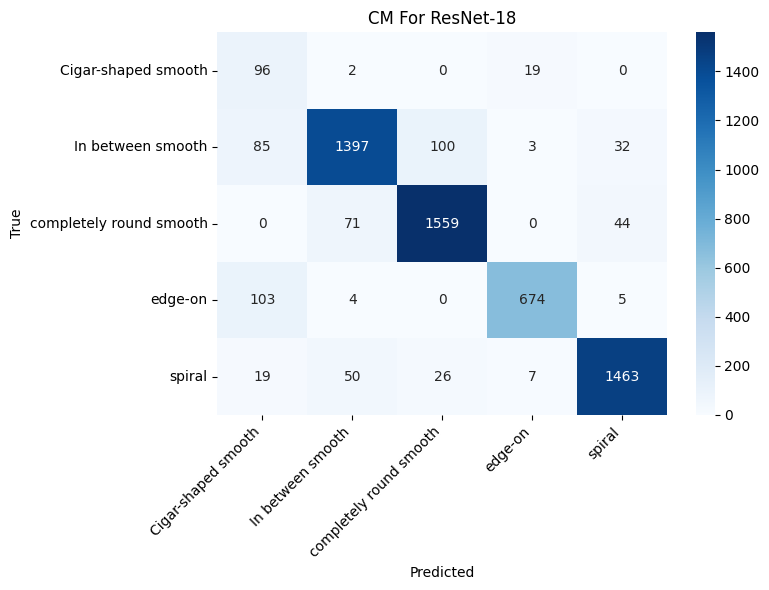


Classification Report:
                         precision    recall  f1-score   support

    Cigar-shaped smooth       0.32      0.82      0.46       117
      In between smooth       0.92      0.86      0.89      1617
completely round smooth       0.93      0.93      0.93      1674
                edge-on       0.96      0.86      0.91       786
                 spiral       0.95      0.93      0.94      1565

               accuracy                           0.90      5759
              macro avg       0.81      0.88      0.82      5759
           weighted avg       0.92      0.90      0.91      5759



In [11]:
# evaluation
resnet.eval()
all_preds = []
all_labels = []

# batch
with torch.no_grad():
    for images, labels in resnet_test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = resnet(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# array conversion and retrieval
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
class_names = resnet_test_dataset.classes
cm = confusion_matrix(all_labels, all_preds)

# plot creation
plt.figure(figsize = (8, 6))
sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Blues',
            xticklabels = class_names, yticklabels = class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('CM For ResNet-18')
plt.xticks(rotation = 45, ha = 'right')
plt.tight_layout()
plt.show()

# classification report
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names = class_names))

### **<u>5.1) CM and Classification Interpretation</u>**

- Rows represent the **true** class.
- Columns represent the **predicted** class.
- The diagonal (top-left to bottom-right) represents the correct predictions and all the other values are mistakes.

Definitions from the classification report:
- `precision`: How often the model was right in predicting a class. A lower value indicates **more false positives**.
- `recall`: Of all the instances of a specific class, how many did the model actually find.
- `f1-score`: The **harmonic mean $H$** of the `precision` and `recall` where the harmonic mean is the reciprocal of the mean of the reciprocal of each number. Mathematically:

$$\Huge \color{orange}{H} = \frac{n}{\sum_{i = 1}^{n} \frac{1}{x_i}} $$

with $n = 2$ since we have two numbers - `precision` and `recall` and $x$ representing the values of each of these.
- `support`: The number of actual test images of each class there were.

---

1. Cigar-shaped smooth:
   - The majority of misclassifications were with edge-on galaxies. This makes sense since the visual distinction between these two classes is very low.
   - Low `precision` indicates that the model is **wrong** most of the time. This is also justified given the amount of images available for this class alone compared to the others.

---

2. In between smooth:
   - High precision with slight misclassification with **completely round smooth** which makes sense since both these classes only really differ in how circular they appear.

---

3. Completely round smooth:
   - Minimal confusion with the other classes.

---

4. Edge-on:
   - Some misclassification with the **cigar-shaped smooth** class just like before.

---

5. Spiral:
   - High scores with minimal confusion which is also understandable since this class is probably the most distinct out of the 5 that we have.
  
---

Conclusively, the one weak spot is the cigar-shaped galaxies which is mainly attributed to its class imbalance and visual similarity with the edge-on class.

### **<u>5.2) Visualising Predictions</u>**

Now we can see the model in action by showing some example images from our dataset and seeing if the model is correctly predicting them or not.

---

1. Denormalisation:
   - Function that reverses the normalisation applied in section **4.1** in order to restore the original pixel values.
   - `.view(3, 1, 1)` reshapes `mean` and `std` correctly across the 3 colour channels.

---

2. Evaluation:
   - Similar to before but now we add an iteration that skips a random number of batches between 1-50. This randomises the images that are plotted each run.
  
---

3. Batch loop:
   - Exactly like before - runs the batch through the model without gradients and obtains the predicted class for each image.
  
---

4. Plotting:
   - Create a 2x5 plot of images and convert the 2D array of the subplot axes into a 1D list for indexing.
   - Loops through the first 10 images in a batch and takes the i-th image to apply the denormalisation on.
   - `.permute(1, 2, 0)` reorders dimensions from `(channels, height, width)` to `(height, width, channels)` which matplotlib requires. These are then converted to a numpy array.
   - Matplotlib also requires float images to be in the 0-1 range. `np.clip(img, 0, 1)` essentially removes values just outside this range.
   - Obtain the predicted and true names from the integer labels as an index.
   - Display the images with `.imshow(img)`, sets the titles and shows whether the prediction is correct or not via green or red text.
   - Remove the axis markers for a cleaner visual.

---

> **Note on images seen below:**
> - `torch.randint(1, 50, (1,))` is affected by `global_seed` at the beginning but **only when the notebook runs from top to bottom sequentially**. Because of this, performing a <u>restart and run all</u> will produce the **same 10 images each time**.
> - Running the cell below **individually** afterwards will produce a different random set of 10 images.

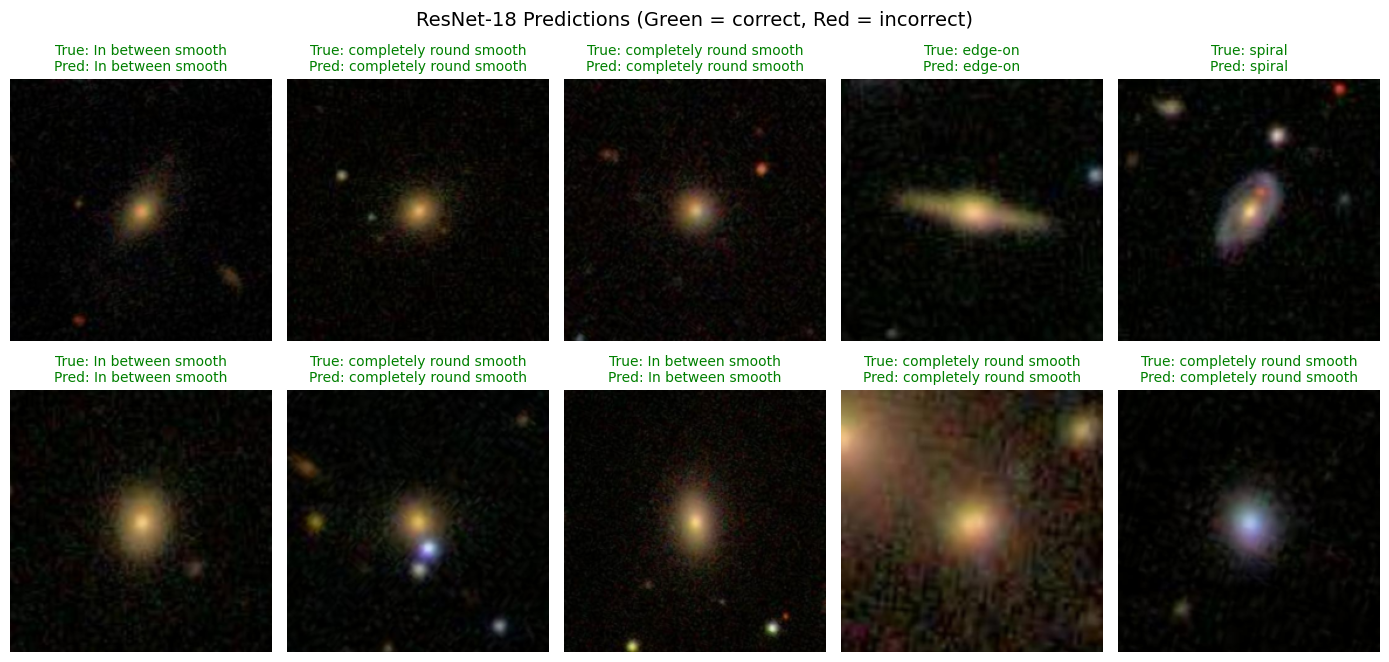

In [12]:
# denormalisation function
def denormalise(tensor):
    """
    Reverses the ImageNet normalisation applied during preprocessing to restore natural pixel values.

    Args:
        tensor: normalised image tensor of shape (3, H, W).

    Returns:
        result: denormalised image tensor with restored pixel values.
    """
    
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    result = (tensor * std) + mean

    return result

# evaluation
resnet.eval()
data_iteration = iter(resnet_test_loader)
for _ in range(torch.randint(1, 50, (1,)).item()):
    images, labels = next(data_iteration)
    images, labels = images.to(device), labels.to(device)

# batch
with torch.no_grad():
    outputs = resnet(images)
    _, predicted = torch.max(outputs, 1)

# plots
fig, axes = plt.subplots(2, 5, figsize = (14, 7))
axes = axes.flatten()

for i in range(10):
    img = denormalise(images[i].cpu())
    img = img.permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)

    true_label = class_names[labels[i].item()]
    pred_label = class_names[predicted[i].item()]
    correct = labels[i] == predicted[i]

    axes[i].imshow(img)
    axes[i].set_title(f"True: {true_label}\nPred: {pred_label}", color = 'green' if correct else 'red', fontsize = 10)
    axes[i].axis('off')

plt.suptitle('ResNet-18 Predictions (Green = correct, Red = incorrect)', fontsize = 14)
plt.tight_layout()
plt.show()

### **<u>5.3) Saving and Loading the model</u>**

The main point of having this cell is to avoid retraining from scratch every time the:

- notebook is closed and reopened.
- kernel is restarted.
- notebook is ran on another machine.

This is because the trained model only exists in the machine's RAM while the notebook is running and the trained weights would be gone if we didn't save. By doing so, the weights get saved permanently to the disk and we can load the model straight back in without any unnecessary retraining.

---

1. Saving:
   - `state_dict()` extracts the weights from the model as a Python dictionary and `torch.save` writes this to the disk as `'classifier.pth'`.
   - `.pth` is just a PyTorch file format for saving machine learning models with the inclusion of its weights and biases.

---

2. Loading:
   - `weights = None` creates a fresh ResNet-18 model with random weights rather than pretrained ones from **ImageNet**.
   - Freeze the layers just like in the training setup since the loaded model and the saved model **must match exactly**.
   - Replace the final layer to match the 5-class version we have. Without this, saved weights for this layer wouldn't match ResNet's final layer and would therefore fail to load.
   - Read the `.pth` file from before back into a Python dictionary with `torch.load`.
   - `load_state_dict` copies the weights over and `map_location = device` ensures the weights load onto the correct device (without this, weights saved on a machine **with a GPU** could fail to load on a **CPU-only machine**).
   - Move the model to the GPU and switch to evaluation mode.

In [13]:
# saving
torch.save(resnet.state_dict(), 'classifier.pth')

# loading
resnet_loaded = models.resnet18(weights = None)
for param in resnet_loaded.parameters(): # freezing
    param.requires_grad = False
resnet_loaded.fc = nn.Linear(resnet_loaded.fc.in_features, 5)
resnet_loaded.load_state_dict(torch.load('classifier.pth', map_location = device))
resnet_loaded = resnet_loaded.to(device)
resnet_loaded.eval();

## **<u>6) Defining the Inference Function</u>**

This final part brings everything together and we can test the model's predictions on external images (i.e. predict a random galaxy's class that is **not** in the training dataset).

---

1. File loading and preprocessing:
   - Open the image file saved on the disk using `PIL`.
   - `.convert('RGB')` ensures consistency of 3 colour channels which ResNet expects and improves robustness to different image formats.
   - *Optionally* display the image that is called with the `predict_galaxy` function. By default, `show_image = False` to ensure the image is only showed when explicitly asked to do so by setting `show_image = True` in the function call.
   - Apply the same preprocessing done earlier during testing - **resize to 224x224, convert to a tensor and then normalise**. The training images went through this preprocessing so any external images **must** go through this aswell.
   - Add a batch dimension with `.unsqueeze(0)` since the model expects **4 inputs - (batch_size, 3, 224, 224)** but a single images has **3 - (3, 224, 224)**.

---

2. Evaluation and probabilities:
   - Switch to evaluation mode, disable gradients and run the new image through the model.
   - Convert the 5 raw scores from `outputs` into probabilities that sum to 1 with `softmax` and remove the batch dimension with `[0]` at the end since there is only one image.
   - Find the highest probability with `torch.max(probabilities, 0)`. The '0' is used so that we have a 1D tensor of 5 values after removing the batch dimension previously, and we obtain the maximum probability value (`confidence`) and its position (`predicted_index`) which is used to find the class name.
   - Convert both of these from PyTorch scalars to plain Python numbers.

---

3. Results and testing:
   - Print each class and its probability percentage.
   - Print a final prediction and confidence level.
   - Test the function on an external image in a new `demo_images` folder.

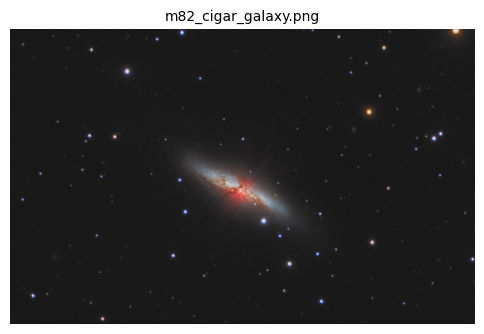

All class probabilities:

Cigar-shaped smooth = 3.9%
In between smooth = 2.4%
completely round smooth = 0.3%
edge-on = 90.4%
spiral = 3.1%

Final Prediction = edge-on with 90.4% confidence.


In [14]:
def predict_galaxy(image_path, show_image = False):
    """
    Takes any galaxy image in the file directory and returns the predicted class.

    Args:
        image_path: the path to the image file
        show_image: if true, displays the image alongside the prediction. False by default.
    """

    # image loading
    image = Image.open(image_path).convert('RGB')
    if show_image:
        plt.figure(figsize = (6, 6))
        plt.imshow(image)
        plt.axis('off')
        plt.title(f"{os.path.basename(image_path)}", fontsize = 10)
        plt.show()
        
    transformed = resnet_test_transform(image)
    input_tensor = transformed.unsqueeze(0).to(device)
    
    # eval and probabilities
    resnet_loaded.eval()
    with torch.no_grad():
        outputs = resnet_loaded(input_tensor)

    probabilities = torch.softmax(outputs, dim = 1)[0]

    confidence, predicted_index = torch.max(probabilities, 0)
    predicted_class = class_names[predicted_index.item()]
    confidence_percent = confidence.item() * 100


    # results and testing
    print(f"All class probabilities:")
    print()
    for name, prob in zip(class_names, probabilities):
        print(f"{name} = {prob.item() * 100:.1f}%")
    print(f"\nFinal Prediction = {predicted_class} with {confidence_percent:.1f}% confidence.")


# final test
predict_galaxy('demo_images/m82_cigar_galaxy.png', show_image = True)